In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import soundfile as sf
import librosa
import numpy as np
import IPython.display as ipd
import tqdm
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import sounddevice as sd
# Define the device
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS device")
else:
    device = torch.device("cpu")
    print("MPS not available, using CPU")

Using MPS device


In [2]:
# device = torch.device("cpu")

In [3]:
class AudioResidualLSTM(nn.Module):
    def __init__(self, input_channels=1, hidden_dim=64, num_layers=2, kernel_size=3):
        """
        Args:
            input_channels: 1 for mono, 2 for stereo.
            hidden_dim: The 'memory' size of the LSTM.
            num_layers: How many LSTM layers to stack.
            kernel_size: Used for a pre-processing convolution to help the LSTM.
        """
        super(AudioResidualLSTM, self).__init__()

        self.input_channels = input_channels
        self.hidden_dim = hidden_dim

        # 1. Pre-processing Layer: A small 1D Convolution.
        # This helps the model look at a tiny window of samples
        # rather than just a single isolated point.
        self.pre_conv = nn.Conv1d(
            in_channels=input_channels,
            out_channels=hidden_dim,
            kernel_size=kernel_size,
            padding=kernel_size // 2
        )

        # 2. The Temporal Engine: LSTM
        # batch_first=True means input shape is (Batch, Sequence, Features)
        self.lstm = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

        # 3. The Projection Head: The FC/Linear Layer
        # This maps the high-dimensional LSTM state back to audio amplitude.
        self.fc = nn.Linear(hidden_dim, input_channels)

    def forward(self, x, hidden=None):
        """
        x: Input tensor of shape (Batch, Sequence, Channels)
           Example: (32, 1024, 1) -> 32 chunks of 1024 samples each.
        """
        # Store the original input for the residual connection
        identity = x

        # --- Step 1: Pre-processing ---
        # Conv1d expects (Batch, Channels, Sequence), so we permute
        x_conv = x.permute(0, 2, 1)
        x_conv = self.pre_conv(x_conv)

        # Bring it back to (Batch, Sequence, Hidden_Dim) for the LSTM
        x_features = x_conv.permute(0, 2, 1)

        # --- Step 2: Temporal Modeling ---
        # lstm_out shape: (Batch, Sequence, Hidden_Dim)
        lstm_out, new_hidden = self.lstm(x_features, hidden)

        # --- Step 3: Projection ---
        # Map hidden features back to audio channels
        # residual shape: (Batch, Sequence, Channels)
        residual = self.fc(lstm_out)

        # --- Step 4: The Residual Connection (CRITICAL) ---
        # We add the learned distortion back to the original clean signal.
        # Output = Clean_Signal + Learned_Distortion
        output = identity + residual

        return output, new_hidden

In [4]:
class Config:
    sr          = 44100      # Match your LSTM notebook sampling rate
    batch_size  = 8
    block       = 512        # The seq_len used in inference

    # HP search / training budget
    n_trials        = 20
    epochs_search   = 3
    steps_search    = 40
    epochs_final    = 15
    steps_final     = 80
    patience        = 4

    study_name   = "distortion_lstm"
    storage_path = "sqlite:///hp_study_lstm.db"
    best_hp_path = "best_hp_lstm.json"

cfg = Config()

def load_wav(path, sr):
    audio, _ = librosa.load(path, sr=sr)
    return audio.astype(np.float32)

def prepare_data():
    print("Loading audio...")
    x = load_wav("Data/ML Guitar_ Initial_Data_cut.wav", cfg.sr)
    y = load_wav("Data/ML Guitar_ Target Data_Cut.wav", cfg.sr)
    n = min(len(x), len(y))
    x, y = x[:n], y[:n]

    # Train / Test Split
    split = int(0.8 * n)
    x_tr, x_te = x[:split], x[split:]
    y_tr, y_te = y[:split], y[split:]

    # Global max normalisation
    peak_x = np.max(np.abs(x_tr)) + 1e-8
    peak_y = np.max(np.abs(y_tr)) + 1e-8
    x_tr, x_te = x_tr / peak_x, x_te / peak_x
    y_tr, y_te = y_tr / peak_y, y_te / peak_y

    return (x_tr, y_tr, x_te, y_te), (peak_x, peak_y)


In [5]:
def pre_emphasis(x, coeff):
    return x[:, 1:, :] - coeff * x[:, :-1, :]

def esr_loss(pred, target, coeff, eps=1e-8):
    pe_pred   = pre_emphasis(pred, coeff)
    pe_target = pre_emphasis(target, coeff)
    num = torch.sum((pe_pred - pe_target) ** 2)
    den = torch.sum(pe_target ** 2) + eps
    return num / den

def sample_batch(x, y, seq_len, device):
    n = len(x)
    starts = torch.randint(0, n - seq_len, (cfg.batch_size,))
    offs   = torch.arange(seq_len)
    idx    = starts.unsqueeze(1) + offs.unsqueeze(0)

    xb = x[idx].unsqueeze(-1).to(device)
    yb = y[idx].unsqueeze(-1).to(device)
    return xb, yb


In [6]:
import optuna
import time
import copy
import os
import json

def run_training(hp, data, device, epochs, steps, trial=None, patience=None, verbose=False):
    x_tr, y_tr, x_te, y_te = data
    x_tr = torch.from_numpy(x_tr)
    y_tr = torch.from_numpy(y_tr)
    x_te = torch.from_numpy(x_te).unsqueeze(0).unsqueeze(-1).to(device)
    y_te = torch.from_numpy(y_te).unsqueeze(0).unsqueeze(-1).to(device)

    # Initialize your architecture using hyper-parameters
    model = AudioResidualLSTM(input_channels=1, hidden_dim=hp["hidden"], num_layers=hp.get("layers", 2)).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=hp["lr"], weight_decay=hp["weight_decay"])

    best_loss  = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    wait = 0

    for epoch in range(epochs):
        model.train()
        t0 = time.time()
        for _ in range(steps):
            xb, yb = sample_batch(x_tr, y_tr, hp["seq_len"], device)
            pred, _ = model(xb)

            # Skip warmup section of the sequence when calculating loss
            warmup = hp["seq_len"] // 8
            loss = esr_loss(pred[:, warmup:], yb[:, warmup:], hp["pre_emph"])

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        model.eval()
        with torch.no_grad():
            pred, _ = model(x_te)
            test_loss = esr_loss(pred, y_te, hp["pre_emph"]).item()

        if test_loss < best_loss - 1e-4:
            best_loss  = test_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
            flag = "  <-- best"
        else:
            wait += 1
            flag = ""

        if verbose:
            print(f"  Epoch {epoch+1:2d}/{epochs}  "
                  f"test ESR={test_loss:.4f}  ({time.time()-t0:.1f}s){flag}")

        if trial is not None:
            trial.report(test_loss, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

        if patience is not None and wait >= patience:
            if verbose:
                print(f"  Early stop. Best test ESR={best_loss:.4f}")
            break

    return best_loss, best_state

def make_objective(data, device):
    def objective(trial):
        hp = {
            "lr"          : trial.suggest_float("lr", 1e-3, 2e-2, log=True),
            "hidden"      : trial.suggest_categorical("hidden", [32, 64]),
            "layers"      : trial.suggest_categorical("layers", [1, 2]),
            "seq_len"     : trial.suggest_categorical("seq_len", [256, 512]),
            "pre_emph"    : trial.suggest_float("pre_emph", 0.7, 0.95),
            "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True),
        }
        best_loss, _ = run_training(hp, data, device, epochs=cfg.epochs_search, steps=cfg.steps_search, trial=trial)
        return best_loss
    return objective

def load_best_hp():
    if not os.path.exists(cfg.best_hp_path):
        return None
    with open(cfg.best_hp_path) as f:
        record = json.load(f)
    print(f"Loaded best HPs from {cfg.best_hp_path} "
          f"(search ESR={record['search_esr']:.4f})")
    return record["params"]


In [7]:
@torch.no_grad()
def bench(model, n=100):
    model = model.to("cpu").eval()
    x = torch.zeros(1, cfg.block, 1)
    h = None
    y, h = model(x, h)
    t0 = time.perf_counter()
    for _ in range(n):
        y, h = model(x, h)
    dt = (time.perf_counter() - t0) / n
    budget = cfg.block / cfg.sr * 1000
    print(f"\n{dt*1000:.2f} ms/block   (budget {budget:.1f} ms)   "
          f"{'OK' if dt*1000 < budget else 'TOO SLOW'}")

@torch.no_grad()
def render_test(model, data, peaks, device):
    x_tr, y_tr, x_te, y_te = data
    peak_x, peak_y = peaks
    model.eval()
    xt = torch.from_numpy(x_te).unsqueeze(0).unsqueeze(-1).to(device)
    pred, _ = model(xt)
    pred = pred.squeeze().cpu().numpy()
    sf.write("predicted_distortion.wav", pred * peak_y, cfg.sr)
    sf.write("test_input_clean.wav",     x_te * peak_x, cfg.sr)
    sf.write("test_target_true.wav",     y_te * peak_y, cfg.sr)
    print("\nSaved predicted_distortion.wav / test_input_clean.wav / test_target_true.wav")

@torch.no_grad()
def analyze_segment(model, data, peaks, device, plot_start_sec=1.0, plot_dur_sec=1.0):
    x_tr, y_tr, x_te, y_te = data
    peak_x, peak_y = peaks
    model.eval()

    xt = torch.from_numpy(x_te).unsqueeze(0).unsqueeze(-1).to(device)
    pred, _ = model(xt)
    pred = pred.squeeze().cpu().numpy()
    true = y_te

    err = pred - true
    esr = np.sum(err ** 2) / (np.sum(true ** 2) + 1e-8)

    abs_err = np.abs(err)
    n_top = max(1, int(0.001 * len(abs_err)))
    worst = np.sort(abs_err)[-n_top:]
    worst_mean = worst.mean()

    print("\n================ Full test-set metrics ================")
    print(f"Test samples                  : {len(true):,} "
          f"({len(true)/cfg.sr:.1f}s)")
    print(f"ESR (whole test set)          : {esr:.4f}")
    print(f"Worst 0.1% deviations ({n_top:,} samples)")
    print(f"  mean |error| (normalized)   : {worst_mean:.4f}")
    print(f"  mean |error| (output scale) : {worst_mean * peak_y:.4f}")
    print("=======================================================")

    a = int(plot_start_sec * cfg.sr)
    b = a + int(plot_dur_sec * cfg.sr)
    b = min(b, len(true))
    a = max(0, min(a, b - 1))

    true_w = true[a:b]
    pred_w = pred[a:b]
    err_w  = err[a:b]
    t = np.arange(len(true_w)) / cfg.sr + a / cfg.sr

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    ax1.plot(t, true_w, label="True",      linewidth=0.8)
    ax1.plot(t, pred_w, label="Predicted", linewidth=0.8, alpha=0.8)
    ax1.set_ylabel("Amplitude (norm.)")
    ax1.set_title(f"True vs Predicted  ({plot_start_sec:.2f}s window)  |  "
                  f"full-set ESR={esr:.4f}")
    ax1.legend(loc="upper right")
    ax1.grid(alpha=0.3)

    ax2.plot(t, err_w, color="crimson", linewidth=0.8)
    thresh = worst.min()
    ax2.axhline( thresh, color="k", linestyle="--", linewidth=0.7,
                 label=f"global top-0.1% |err| ≥ {thresh:.3f}")
    ax2.axhline(-thresh, color="k", linestyle="--", linewidth=0.7)
    ax2.set_ylabel("Error (pred - true)")
    ax2.set_xlabel("Time (s)")
    ax2.legend(loc="upper right")
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("segment_analysis.png", dpi=120)
    print("Saved plot: segment_analysis.png")
    plt.show()


In [8]:
print(f"Device: {device}")
data, peaks = prepare_data()

FORCE_SEARCH = False
best = None if FORCE_SEARCH else load_best_hp()


Device: mps
Loading audio...
Loaded best HPs from best_hp_lstm.json (search ESR=0.1960)


In [9]:
# study_name = "distortion_lstm"
# storage = "sqlite:///hp_study_lstm.db"
#
# try:
#     optuna.delete_study(study_name=study_name, storage=storage)
#     print(f"Study '{study_name}' deleted successfully.")
# except Exception as e:
#     print(f"Error: {e}")

In [10]:
if best is None:
    print(f"\n=== Hyperparameter search ===")

    study = optuna.create_study(
        study_name=cfg.study_name,
        storage=cfg.storage_path,
        load_if_exists=True,
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=0),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=4, n_warmup_steps=2),
    )
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    done = len([t for t in study.trials
                if t.state in (optuna.trial.TrialState.COMPLETE,
                               optuna.trial.TrialState.PRUNED)])
    remaining = max(0, cfg.n_trials - done)
    if remaining > 0:
        print(f"  {done} trials already in DB, running {remaining} more "
              f"(target {cfg.n_trials})...")
        study.optimize(make_objective(data, device), n_trials=remaining,
                       show_progress_bar=True)
    else:
        print(f"  {done} trials already in DB (target {cfg.n_trials} reached). "
              f"Skipping search.")

    best = study.best_params
    print("\n=== Best hyperparameters ===")
    for k, v in best.items():
        print(f"  {k:13s}: {v}")
    print(f"  best search ESR: {study.best_value:.4f}")

    best_record = {
        "params"    : best,
        "search_esr": study.best_value,
        "n_trials"  : done + remaining,
        "fixed"     : {
            "sr"        : cfg.sr,
            "batch_size": cfg.batch_size,
        },
    }
    with open(cfg.best_hp_path, "w") as f:
        json.dump(best_record, f, indent=2)
    print(f"  Saved best HPs -> {cfg.best_hp_path}")


In [11]:
print("\n=== Final training with best config ===")
hp = {
    "lr"          : best["lr"],
    "hidden"      : best["hidden"],
    "layers"      : best["layers"],
    "seq_len"     : best["seq_len"],
    "pre_emph"    : best["pre_emph"],
    "weight_decay": best["weight_decay"],
}
best_loss, best_state = run_training(
    hp, data, device,
    epochs=cfg.epochs_final, steps=cfg.steps_final,
    patience=cfg.patience, verbose=True,
)
print(f"\nFinal best test ESR = {best_loss:.4f}")

# Rebuild model with winning architecture and load best weights
model = AudioResidualLSTM(input_channels=1, hidden_dim=hp["hidden"], num_layers=hp["layers"]).to(device)
model.load_state_dict(best_state)

torch.save({
    "state_dict": best_state,
    "hp"        : hp,
    "peaks"     : peaks,
    "test_esr"  : best_loss,
}, "distortion_lstm_model.pt")
print("Saved trained model -> distortion_lstm_model.pt")



=== Final training with best config ===
  Epoch  1/15  test ESR=0.2449  (2.5s)  <-- best
  Epoch  2/15  test ESR=0.2432  (2.2s)  <-- best
  Epoch  3/15  test ESR=0.2117  (2.2s)  <-- best
  Epoch  4/15  test ESR=0.2058  (2.2s)  <-- best
  Epoch  5/15  test ESR=0.2064  (2.2s)
  Epoch  6/15  test ESR=0.2056  (2.2s)  <-- best
  Epoch  7/15  test ESR=0.2051  (2.2s)  <-- best
  Epoch  8/15  test ESR=0.2044  (2.2s)  <-- best
  Epoch  9/15  test ESR=0.2047  (2.3s)
  Epoch 10/15  test ESR=0.2036  (2.2s)  <-- best
  Epoch 11/15  test ESR=0.2034  (2.3s)  <-- best
  Epoch 12/15  test ESR=0.2033  (2.2s)  <-- best
  Epoch 13/15  test ESR=0.2019  (2.2s)  <-- best
  Epoch 14/15  test ESR=0.2026  (2.2s)
  Epoch 15/15  test ESR=0.2021  (2.2s)

Final best test ESR = 0.2019
Saved trained model -> distortion_lstm_model.pt



Saved predicted_distortion.wav / test_input_clean.wav / test_target_true.wav

4.30 ms/block   (budget 11.6 ms)   OK

================ Full test-set metrics ================
Test samples                  : 88,200 (2.0s)
ESR (whole test set)          : 0.0017
Worst 0.1% deviations (88 samples)
  mean |error| (normalized)   : 0.0613
  mean |error| (output scale) : 0.0317
Saved plot: segment_analysis.png


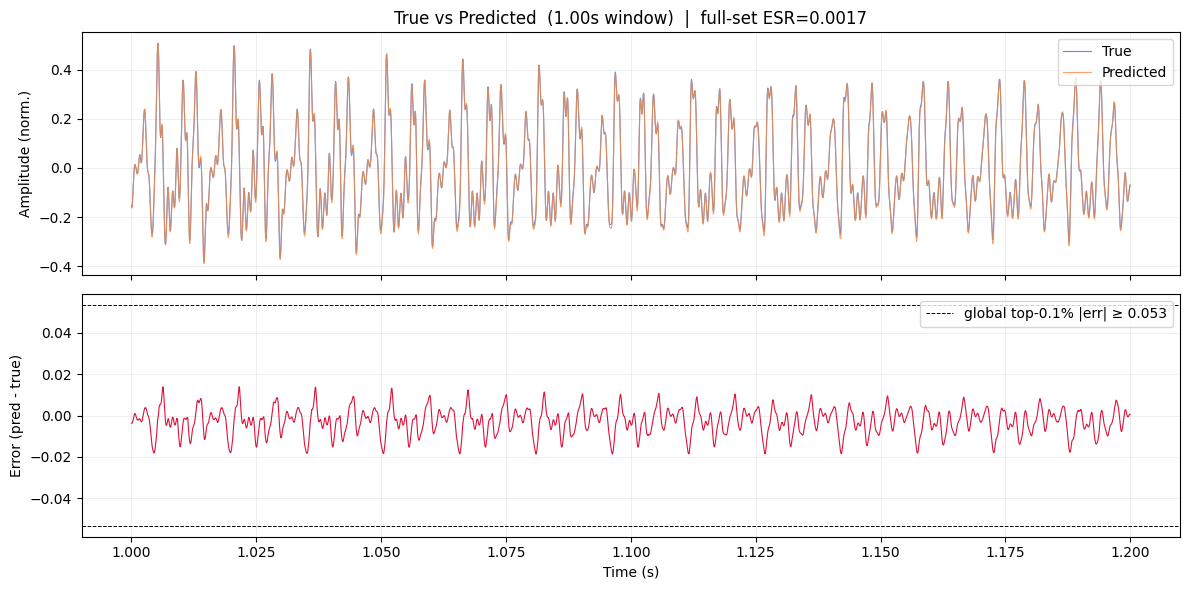

In [12]:
device = torch.device("cpu")
model = model.to(device).eval()
render_test(model, data, peaks, device)
bench(model)
analyze_segment(model, data, peaks, device, plot_start_sec=1.0, plot_dur_sec=0.2)


In [13]:
def stream_audio(model, peaks, input_device=1, output_device=1):
    torch.set_num_threads(1)
    peak_x, peak_y = peaks
    in_scale  = 1.0 / peak_x
    out_scale = peak_y
    model = model.to("cpu").eval()

    state = {"h": None}

    @torch.no_grad()
    def process_audio(indata, outdata, frames, time_info, status):
        if status:
            print(status)

        x = torch.from_numpy(indata[:, 0]).view(1, -1, 1) * in_scale

        # AudioResidualLSTM accepts 'hidden' and returns '(output, new_hidden)'
        y, state["h"] = model(x, hidden=state["h"])

        outdata[:, 0] = (y.view(-1) * out_scale).numpy()

    try:
        with sd.Stream(
            device=(input_device, output_device),
            channels=1,
            samplerate=cfg.sr,
            blocksize=cfg.block,
            latency="low",
            dtype="float32",
            callback=process_audio
        ):
            print(f"Running @ {cfg.sr} Hz, block {cfg.block}. Press Enter to stop.")
            input()
    except sd.PortAudioError as e:
        print(f"\n[Audio error] {e}")
        print(sd.query_devices())


In [14]:
# stream_audio(model, peaks, input_device=1, output_device=1)
